## Импорты библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, learning_curve
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import shap
import warnings
warnings.filterwarnings('ignore')
import optuna

## Загрузка и просмотр данных

In [ ]:
train = pd.read_csv('../data/processed/train_final.csv')
test  = pd.read_csv('../data/processed/test_final.csv')

"\ntrain = pd.read_csv('../data/processed/train_final.csv')\ntest  = pd.read_csv('../data/processed/test_final.csv')\n"

In [ ]:
train.head()

,"IC50, mM","CC50, mM",SI,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,...,fr_thiophene,fr_unbrch_alkane,Feature_Density_Wt,Feature_LogP_Surface,Feature_Arom_Ratio,Feature_Valence_per_Atom,Feature_Complexity,"sqrt_IC50, mM","sqrt_CC50, mM",sqrt_SI
0,102.414420,95.757483,0.935000,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,0.119177,...,0,0,15.022065,0.026199,0.499998,5.384611,504.292077,10.120001,9.785575,0.966954
1,0.044333,8.401080,189.500000,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,0.237676,...,0,0,15.691602,0.020841,0.499998,5.652171,1489.722453,0.210554,2.898462,13.765900
2,4.437964,50.085589,11.285714,5.366084,0.522930,0.522930,0.612606,24.608696,315.457,0.160487,...,0,0,13.715516,0.027420,0.249999,5.478258,875.271184,2.106647,7.077117,3.359422
3,6.827881,682.788051,100.000000,13.317130,0.020658,-4.829339,0.345823,12.400000,439.375,0.436923,...,0,0,14.645828,0.028896,0.999997,5.199998,2468.386395,2.613021,26.130213,10.000000
4,2.003253,70.001455,34.943894,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,0.016184,...,0,0,13.750260,0.028003,0.000000,5.636359,291.054049,1.415363,8.366687,5.911336


In [ ]:
SEED = 42
N_SPLITS = 5
TARGETS = ['sqrt_IC50, mM', 'sqrt_CC50, mM', 'sqrt_SI']
TARGETS_ORIG = ['IC50, mM', 'CC50, mM', 'SI']

def custom_rmse(y_true_ic, y_true_cc, y_true_si, y_pred_ic, y_pred_cc, y_pred_si):
    rmse_ic = np.sqrt(np.mean((y_true_ic - y_pred_ic)**2))
    rmse_cc = np.sqrt(np.mean((y_true_cc - y_pred_cc)**2))
    rmse_si = np.sqrt(np.mean((y_true_si - y_pred_si)**2))
    return (rmse_ic + rmse_cc + rmse_si) / 3.0

In [ ]:
exclude = TARGETS + TARGETS_ORIG + ['index']
feature_cols = [c for c in train.columns if c not in exclude]

X = train[feature_cols].values
y = train[TARGETS].values
y_orig = train[TARGETS_ORIG].values
X_test = test[feature_cols].values

print(f"Train: {X.shape}, Test: {X_test.shape}")
print(f"Таргеты (sqrt): {TARGETS}")

Train: (729, 157), Test: (250, 157)
Таргеты (sqrt): ['sqrt_IC50, mM', 'sqrt_CC50, mM', 'sqrt_SI']


## Параметры моделей

In [ ]:
models_config = {
    'RandomForest': (RandomForestRegressor, {
        'n_estimators': 300, 'max_depth': 10, 'n_jobs': -1
    }),
    'CatBoost': (CatBoostRegressor, {
        'iterations': 500, 'depth': 6, 'learning_rate': 0.05, 'verbose': 0
    }),
    'LightGBM': (LGBMRegressor, {
        'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'verbose': -1
    }),
    'XGBoost': (XGBRegressor, {
        'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'verbosity': 0
    }),
}

## Предсказание

In [ ]:
def train_cv_direct(X, y, X_test, model_class, params):
    """
    Прямое предсказание всех трёх таргетов (IC50, CC50, SI).
    SI предсказывается моделью, а не вычисляется по формуле.
    Кросс-валидация 5 фолдов.
    """
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    preds_oof = np.zeros_like(y)
    preds_test = np.zeros((len(X_test), 3))

    for train_idx, val_idx in kf.split(X):
        fold_val = np.zeros((len(val_idx), 3))
        fold_test = np.zeros((len(X_test), 3))

        for target_idx in range(3):
            model = model_class(**params, random_state=SEED)
            model.fit(X[train_idx], y[train_idx, target_idx])
            fold_val[:, target_idx] = model.predict(X[val_idx])
            fold_test[:, target_idx] = model.predict(X_test)

        preds_oof[val_idx] = fold_val
        preds_test += fold_test / N_SPLITS

    preds_oof[:, 2] = np.clip(preds_oof[:, 2], 0, 4000)
    preds_test[:, 2] = np.clip(preds_test[:, 2], 0, 4000)

    return preds_oof, preds_test

## Прогон всех моделей

In [ ]:
train_cv = train_cv_direct

results = {}
for name, (model_class, params) in models_config.items():
    preds_oof, preds_test = train_cv(X, y, X_test, model_class, params)
    rmse = custom_rmse(
        y_orig[:, 0], y_orig[:, 1], y_orig[:, 2],
        np.clip(preds_oof[:, 0], 0, None)**2,
        np.clip(preds_oof[:, 1], 0, None)**2,
        np.clip(preds_oof[:, 2], 0, None)**2
    )
    results[name] = {'preds_oof': preds_oof, 'preds_test': preds_test, 'rmse': rmse}
    print(f"{name:<15} RMSE: {rmse:.4f}")

best_model = min(results, key=lambda x: results[x]['rmse'])
print(f"\nЛучшая модель: {best_model} (RMSE: {results[best_model]['rmse']:.4f})")

RandomForest    RMSE: 314.1053
CatBoost        RMSE: 310.0537
LightGBM        RMSE: 314.7234
XGBoost         RMSE: 325.8699

Лучшая модель: CatBoost (RMSE: 310.0537)


## Сравнение RMSE всех моделей (barh)

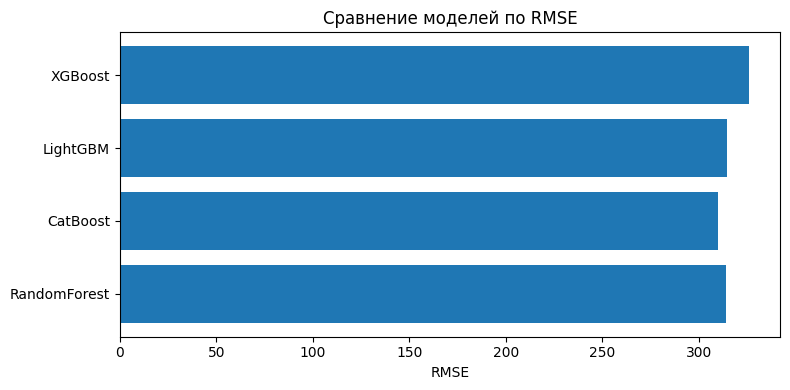

In [ ]:
rmse_values = {name: results[name]['rmse'] for name in results}
plt.figure(figsize=(8, 4))
plt.barh(list(rmse_values.keys()), list(rmse_values.values()))
plt.xlabel('RMSE')
plt.title('Сравнение моделей по RMSE')
plt.tight_layout()
plt.show()

Для задачи одновременного прогнозирования трёх таргетов (sqrt_IC50, sqrt_CC50, sqrt_SI) на очищенном датасете наилучший результат снова показала модель CatBoost с RMSE = 310.05. Остальные ансамблевые методы продемонстрировали более высокую ошибку: RandomForest — 314.11, LightGBM — 314.72, XGBoost — 325.87.

Несмотря на то, что улучшение метрики по сравнению с предыдущими экспериментами оказалось минимальным, именно очищенный датасет обеспечил наилучшее итоговое качество. Это показывает, что удаление почти дублирующихся признаков позволило снизить избыточность данных без потери информативности, а также немного повысить устойчивость модели.

## Важность признаков — для каждой модели, все 3 цели

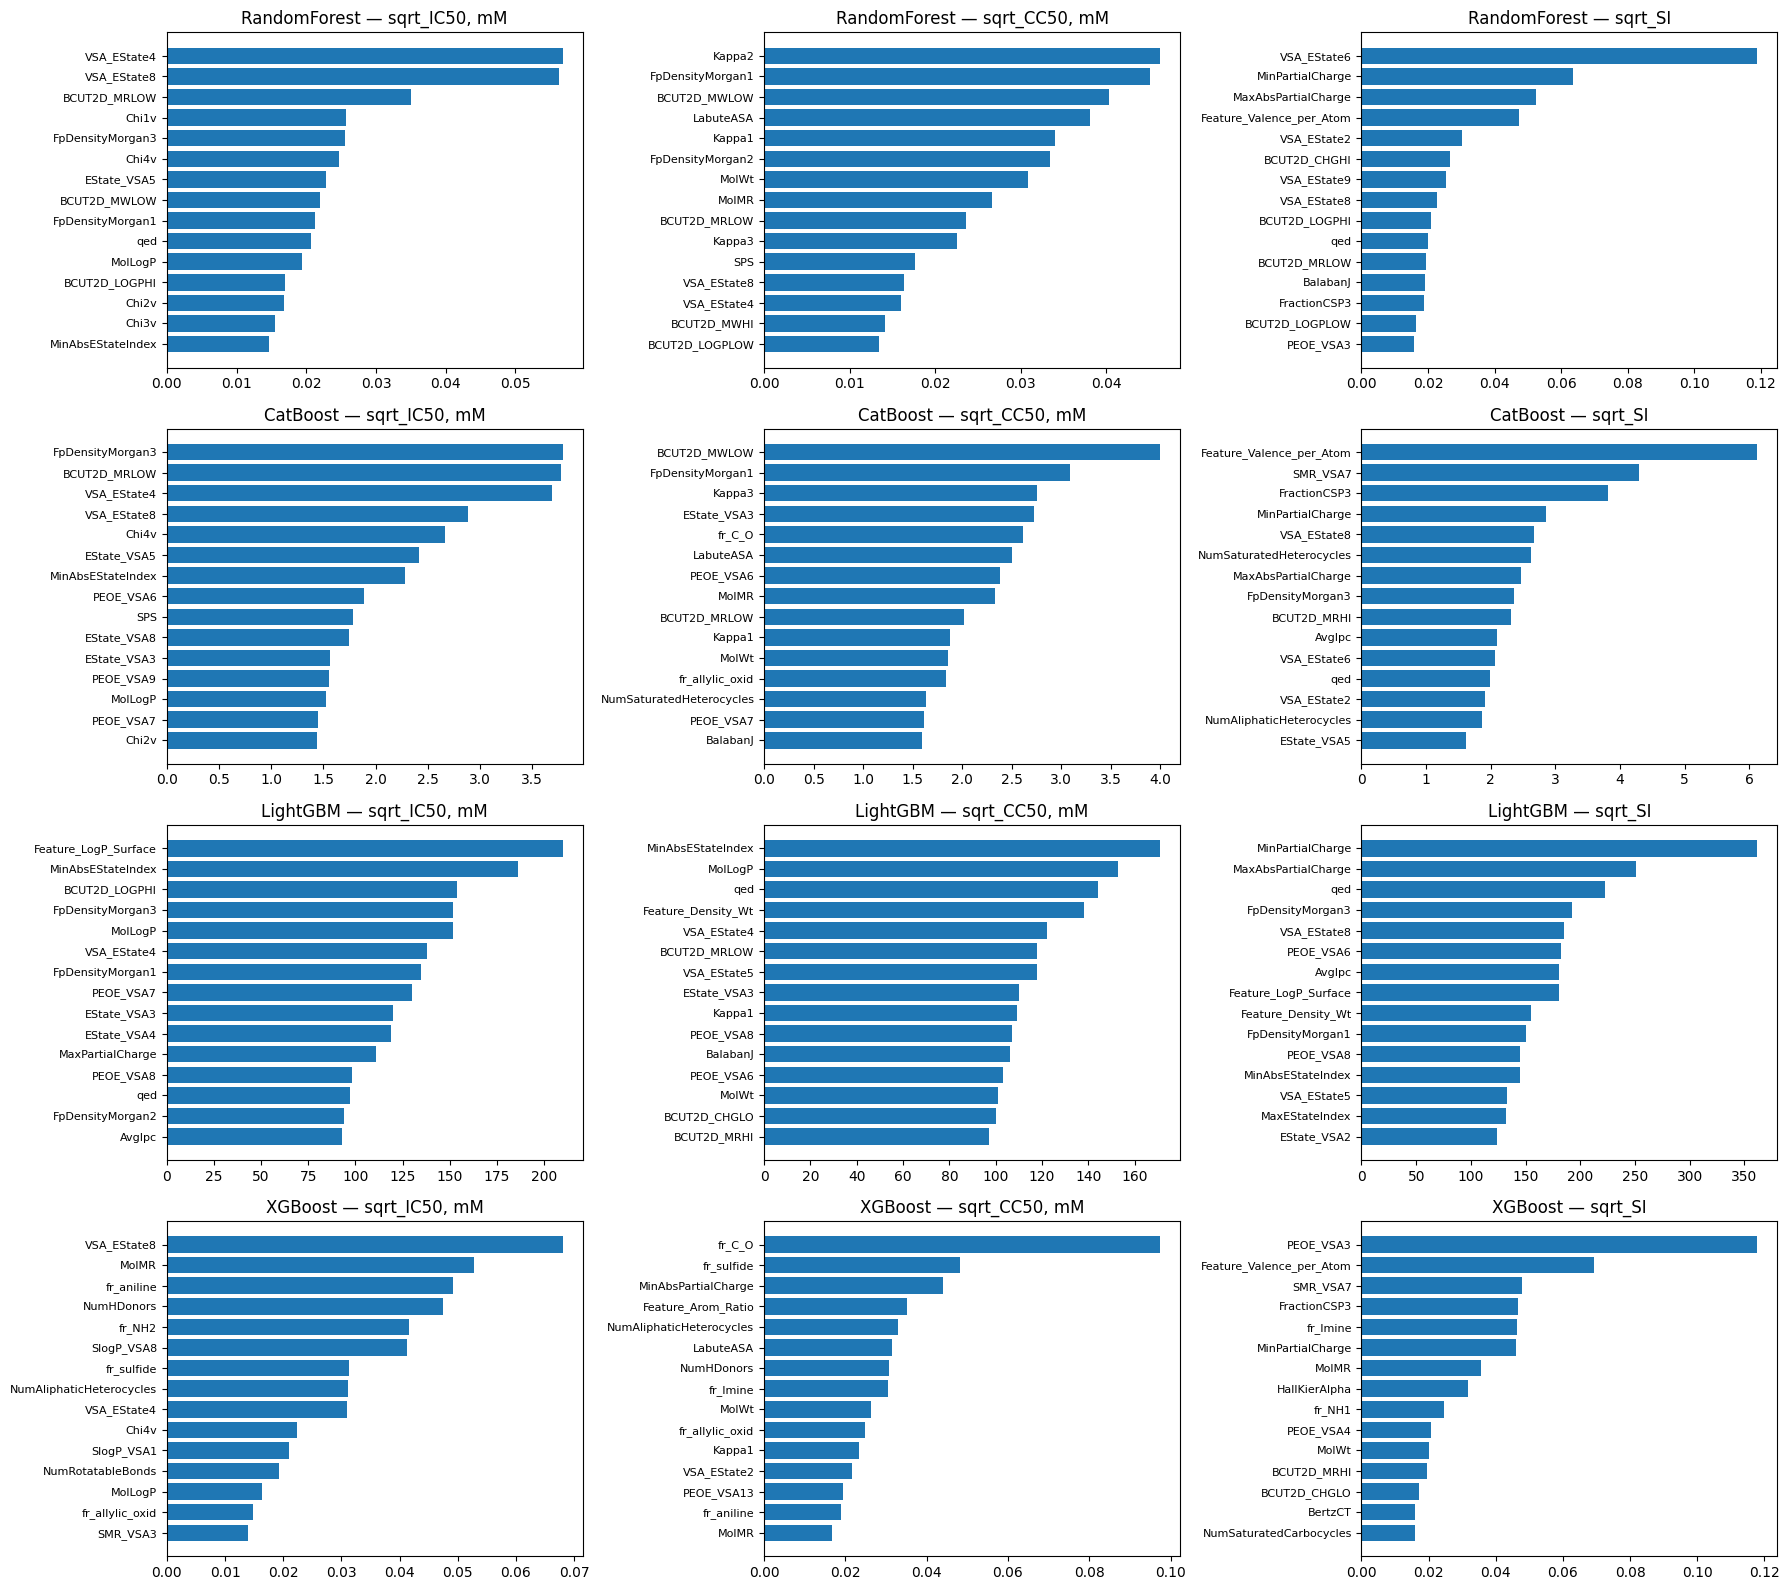

In [ ]:
fig, axes = plt.subplots(len(models_config), 3, figsize=(18, 4 * len(models_config)))

for row, (name, (model_class, params)) in enumerate(models_config.items()):
    for col, target_name in enumerate(TARGETS):
        model = model_class(**params, random_state=SEED)
        model.fit(X, y[:, col])

        if hasattr(model, 'feature_importances_'):
            imp = model.feature_importances_
            top_idx = np.argsort(imp)[-15:]
            axes[row, col].barh(range(15), imp[top_idx])
            axes[row, col].set_yticks(range(15))
            axes[row, col].set_yticklabels([feature_cols[i] for i in top_idx], fontsize=8)
            axes[row, col].set_title(f'{name} — {target_name}')
        else:
            axes[row, col].text(0.5, 0.5, 'Нет importance', ha='center', va='center')

plt.tight_layout()
plt.show()

## Сравнение топ-признаков между CatBoost, LightGBM, XGBoost для каждой цели

In [ ]:
boost_names = ['CatBoost', 'LightGBM', 'XGBoost']

for target_idx, target_name in enumerate(TARGETS):
    top_sets = {}
    for name in boost_names:
        model_class, params = models_config[name]
        model = model_class(**params, random_state=SEED)
        model.fit(X, y[:, target_idx])
        imp = model.feature_importances_
        top10 = set(np.array(feature_cols)[np.argsort(imp)[-10:]])
        top_sets[name] = top10

    common = top_sets[boost_names[0]] & top_sets[boost_names[1]] & top_sets[boost_names[2]]
    pairwise = {}
    for i, n1 in enumerate(boost_names):
        for n2 in boost_names[i+1:]:
            pairwise[f'{n1} & {n2}'] = len(top_sets[n1] & top_sets[n2])

    print(f"\n{target_name}:")
    print(f"  Общих для всех трёх: {len(common)} — {sorted(common)}")
    for pair, count in pairwise.items():
        print(f"  Общих {pair}: {count}/10")


sqrt_IC50, mM:
  Общих для всех трёх: 1 — [np.str_('VSA_EState4')]
  Общих CatBoost & LightGBM: 3/10
  Общих CatBoost & XGBoost: 3/10
  Общих LightGBM & XGBoost: 1/10

sqrt_CC50, mM:
  Общих для всех трёх: 0 — []
  Общих CatBoost & LightGBM: 3/10
  Общих CatBoost & XGBoost: 2/10
  Общих LightGBM & XGBoost: 0/10

sqrt_SI:
  Общих для всех трёх: 1 — [np.str_('MinPartialCharge')]
  Общих CatBoost & LightGBM: 5/10
  Общих CatBoost & XGBoost: 4/10
  Общих LightGBM & XGBoost: 1/10


На очищенном датасете (после удаления практически полных дубликатов) картина важности признаков стала более чёткой и стабильной.
Во всех четырёх моделях сохраняется высокая значимость дескрипторов EState и VSA (особенно VSA_EState4, VSA_EState8, EState_VSA*), а также BCUT2D (BCUT2D_MRLOW, BCUT2D_MWLOW) и Morgan fingerprints (FpDensityMorgan*). Эти группы признаков доминируют практически по всем таргетам, что подтверждает их устойчивую релевантность даже после очистки данных.  

CatBoost и LightGBM продолжают показывать более сфокусированное распределение важности по сравнению с RandomForest и XGBoost. На новом датасете особенно выделяются:

- Для IC50 — VSA_EState*, FpDensityMorgan3, BCUT2D_MRLOW
- Для CC50 — BCUT2D_MWLOW, FpDensityMorgan, MolLogP
- Для SI — Feature_Valence_per_Atom, MnPartialCharge, SMR_VSA*

Удаление дубликатов положительно повлияло на интерпретируемость моделей: топ-признаки стали более согласованными между алгоритмами, а шумовые фичи опустились ниже в рейтинге.

## Графики Actual vs Predicted для всех моделей

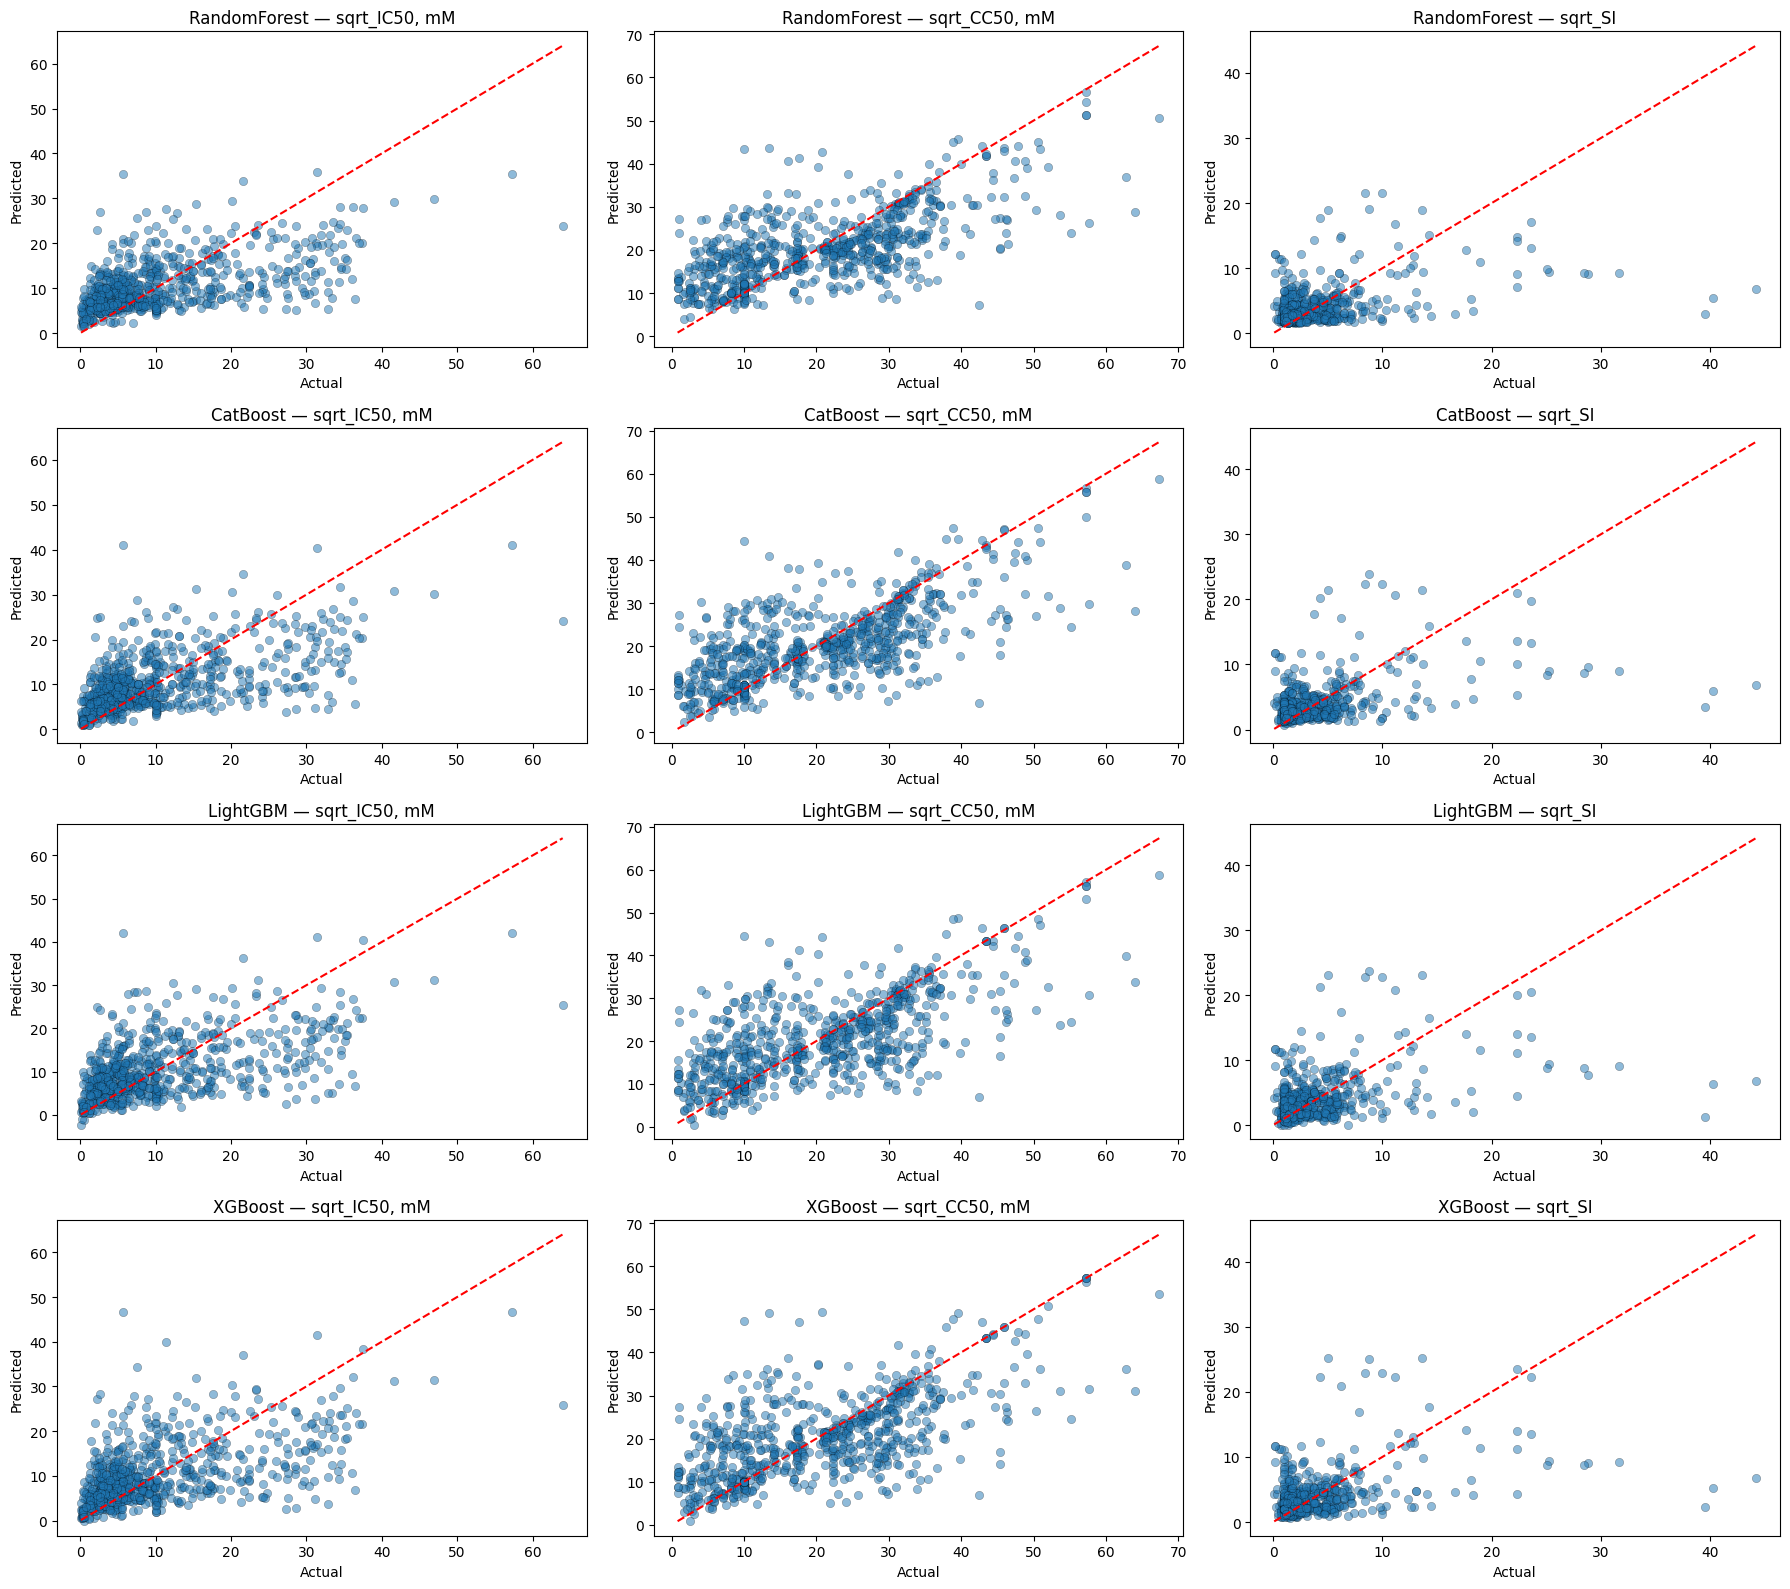

In [ ]:
fig, axes = plt.subplots(len(models_config), 3, figsize=(18, 4 * len(models_config)))

for row, (name, res) in enumerate(results.items()):
    preds_oof = res['preds_oof']
    for col, target_name in enumerate(TARGETS):
        axes[row, col].scatter(y[:, col], preds_oof[:, col], alpha=0.5, edgecolors='k', linewidth=0.3)
        axes[row, col].plot([y[:, col].min(), y[:, col].max()],
                            [y[:, col].min(), y[:, col].max()], 'r--')
        axes[row, col].set_xlabel('Actual')
        axes[row, col].set_ylabel('Predicted')
        axes[row, col].set_title(f'{name} — {target_name}')

plt.tight_layout()
plt.show()

На очищенном датасете все модели сохраняют общий характер предсказаний: хорошо улавливают тренд в области низких и средних значений, но продолжают систематически недооценивать высокие значения sqrt_IC50 и sqrt_CC50. Разброс точек вокруг диагонали остаётся значительным, особенно в правой части графиков.
Удаление дубликатов не привело к кардинальному улучшению качества предсказаний — распределение ошибок осталось похожим на предыдущую версию.

## Residuals для всех моделей

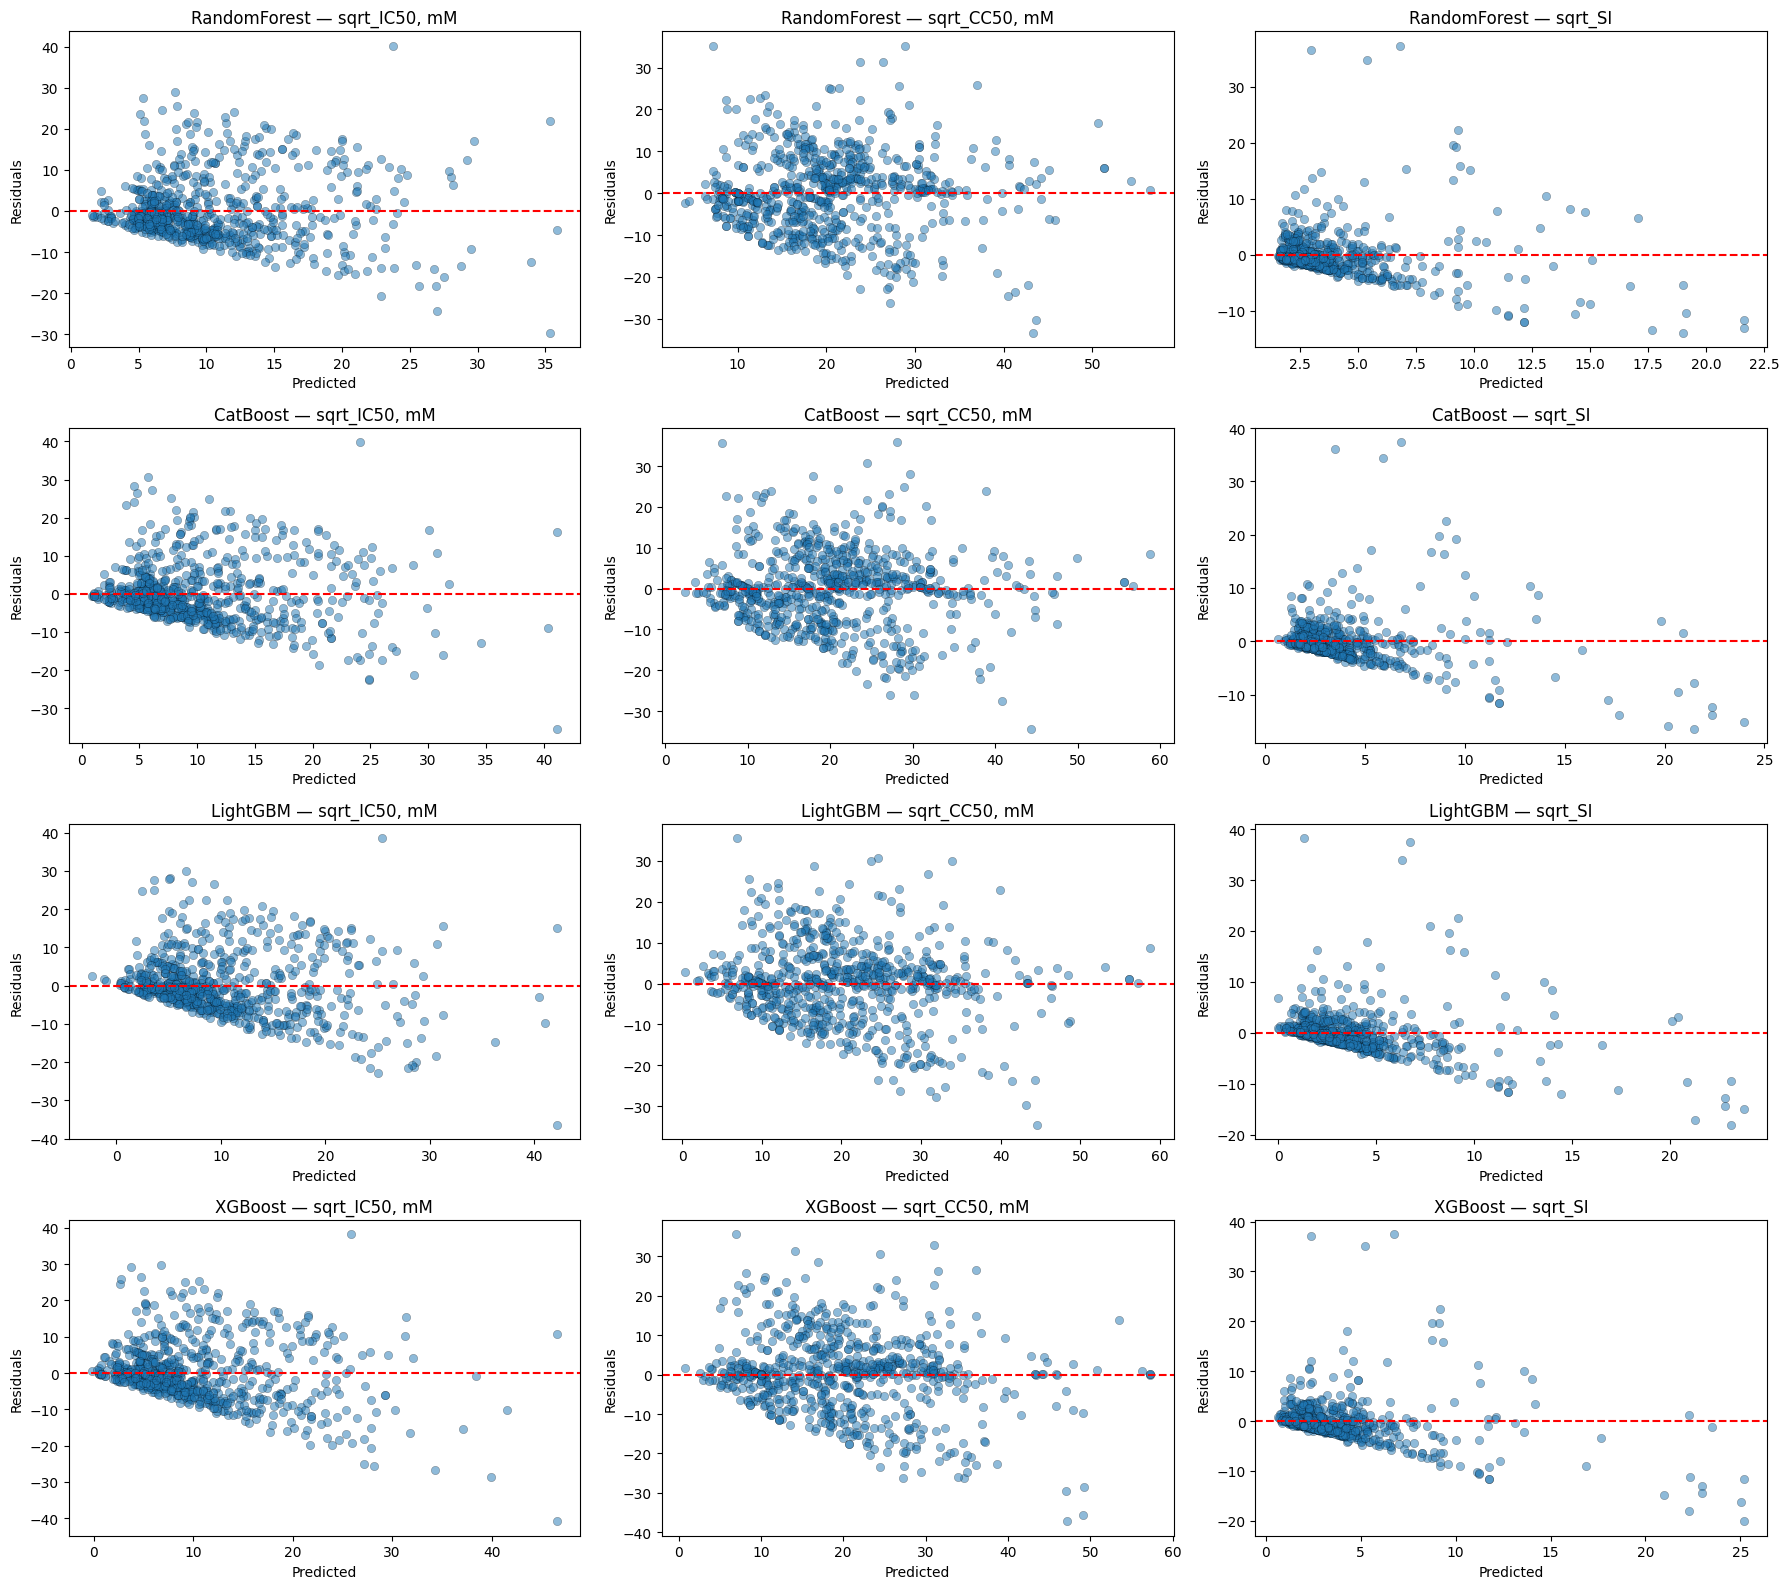

In [ ]:
fig, axes = plt.subplots(len(models_config), 3, figsize=(18, 4 * len(models_config)))

for row, (name, res) in enumerate(results.items()):
    preds_oof = res['preds_oof']
    for col, target_name in enumerate(TARGETS):
        residuals = y[:, col] - preds_oof[:, col]
        axes[row, col].scatter(preds_oof[:, col], residuals, alpha=0.5, edgecolors='k', linewidth=0.3)
        axes[row, col].axhline(y=0, color='r', linestyle='--')
        axes[row, col].set_xlabel('Predicted')
        axes[row, col].set_ylabel('Residuals')
        axes[row, col].set_title(f'{name} — {target_name}')

plt.tight_layout()
plt.show()

На очищенном датасете распределение остатков в целом сохранило прежний характер. Все модели остаются несмещёнными (среднее остатков близко к нулю), однако проблема гетероскедастичности по-прежнему ярко выражена: разброс остатков заметно увеличивается при росте предсказанных значений, особенно на таргетах sqrt_IC50 и sqrt_CC50.

## Кривые обучения для всех моделей

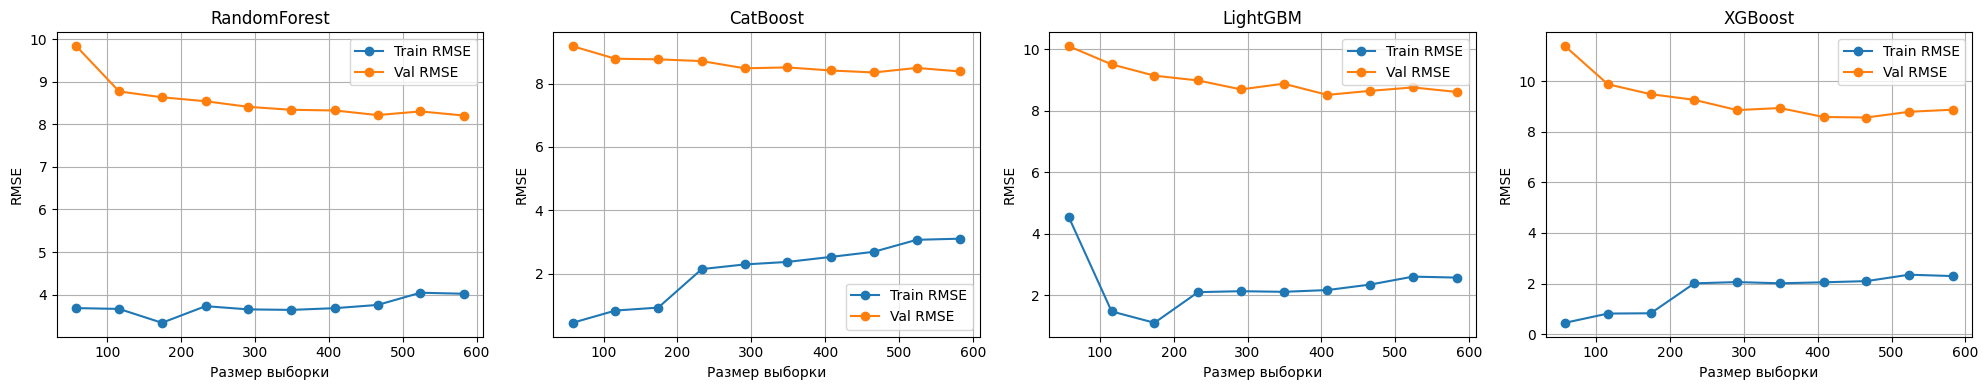

In [ ]:
fig, axes = plt.subplots(1, len(models_config), figsize=(5 * len(models_config), 4))

for idx, (name, (model_class, params)) in enumerate(models_config.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model_class(**params, random_state=SEED),
        X, y[:, 0],
        cv=5,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    ax = axes[idx] if len(models_config) > 1 else axes
    ax.plot(train_sizes, -train_scores.mean(axis=1), 'o-', label='Train RMSE')
    ax.plot(train_sizes, -val_scores.mean(axis=1), 'o-', label='Val RMSE')
    ax.set_xlabel('Размер выборки')
    ax.set_ylabel('RMSE')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

На очищенном датасете кривые обучения демонстрируют схожую картину с предыдущей версией. С увеличением размера выборки Val RMSE у всех моделей постепенно снижается, однако после 300–400 образцов улучшение практически прекращается. Это подтверждает, что текущий объём данных близок к оптимальному для данных моделей.

## SHAP для всех boosts


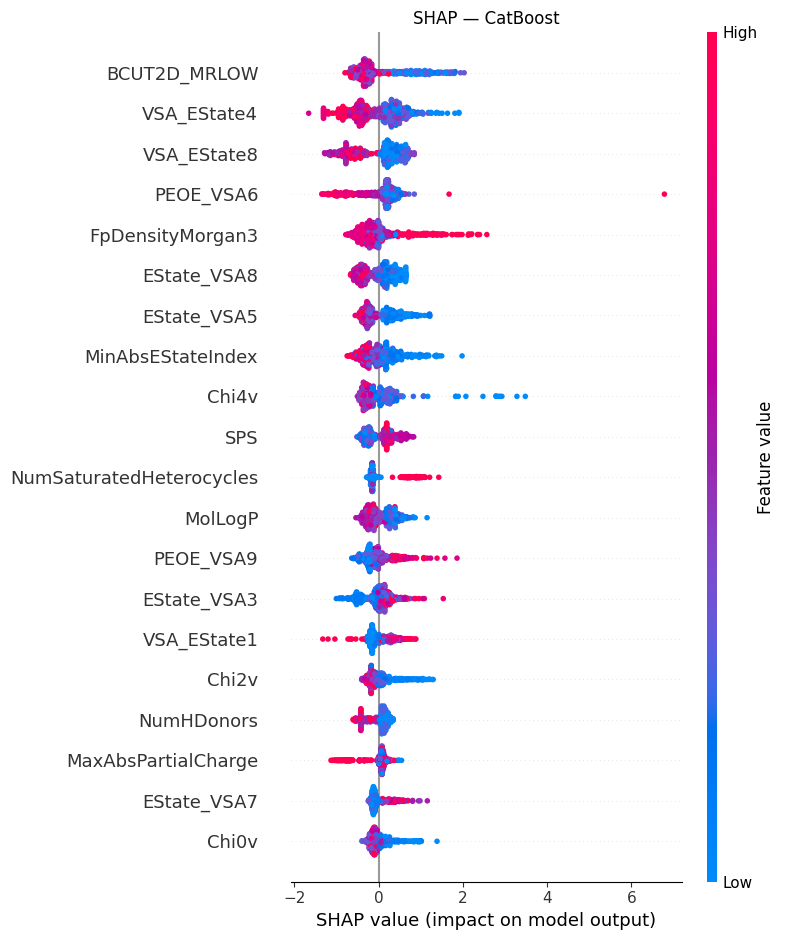

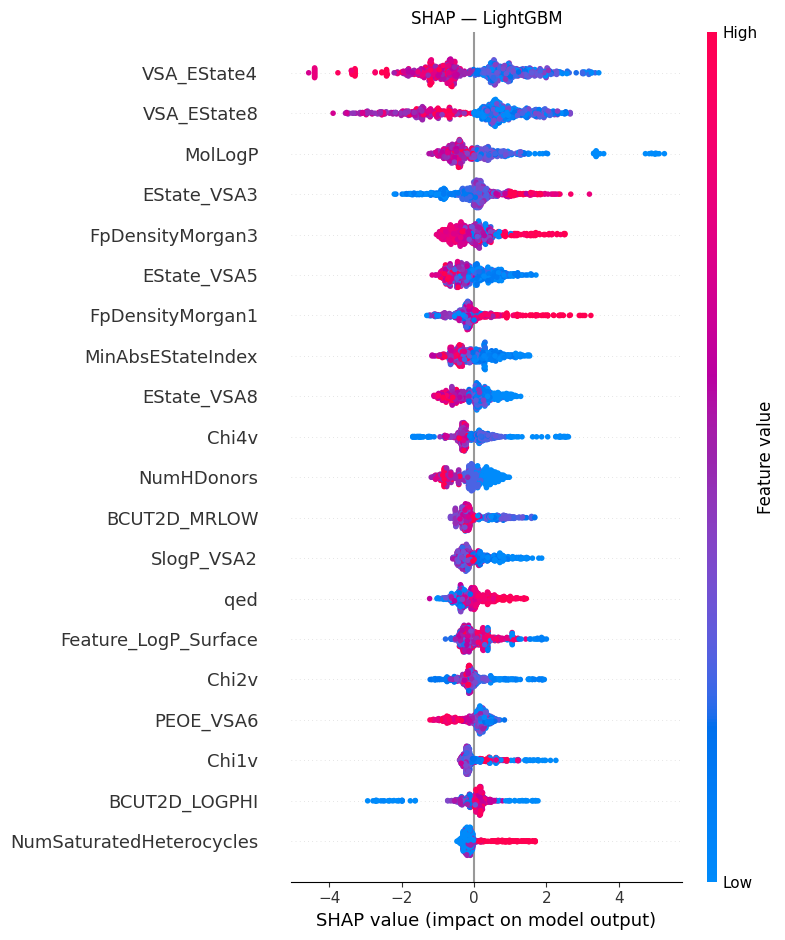

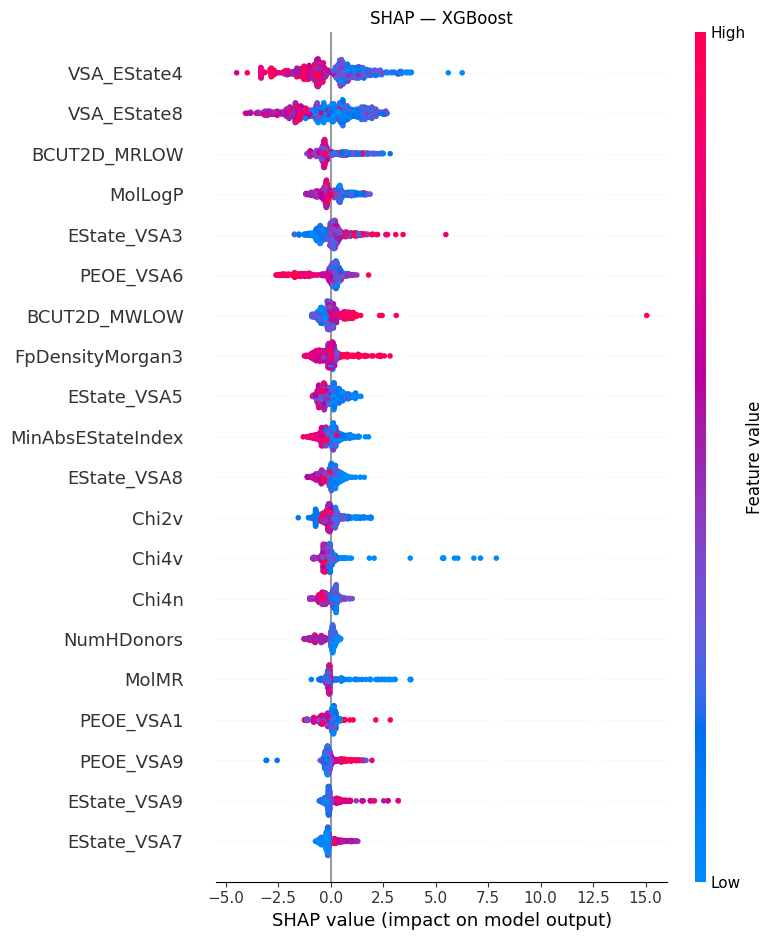

In [ ]:
for name in ['CatBoost', 'LightGBM', 'XGBoost']:
    model_class, params = models_config[name]
    model_shap = model_class(**params, random_state=SEED)
    model_shap.fit(X, y[:, 0])

    explainer = shap.TreeExplainer(model_shap)
    shap_values = explainer.shap_values(X)

    shap.summary_plot(shap_values, X, feature_names=feature_cols, show=False)
    plt.title(f'SHAP — {name}')
    plt.tight_layout()
    plt.show()

На очищенном датасете SHAP-значимости стали более стабильными и согласованными между моделями. Все три алгоритма (CatBoost, LightGBM и XGBoost) выделяют практически одни и те же ключевые признаки как наиболее важные.

## Submissions для всех моделей

In [ ]:
'''
for name, res in results.items():
    preds_test_sqrt = res['preds_test']

    preds_test_orig = preds_test_sqrt ** 2

    submission = pd.DataFrame({
        'index': np.arange(len(preds_test_orig)),
        'IC50': preds_test_orig[:, 0],
        'CC50': preds_test_orig[:, 1],
        'SI': preds_test_orig[:, 2]
    })
    filename = f'submission_{name.lower()}_datamain_3targ.csv'
    submission.to_csv(filename, index=False)
    print(f"Сохранён: {filename}")
'''

'\nfor name, res in results.items():\n    preds_test_sqrt = res[\'preds_test\']\n\n    preds_test_orig = preds_test_sqrt ** 2\n\n    submission = pd.DataFrame({\n        \'index\': np.arange(len(preds_test_orig)),\n        \'IC50\': preds_test_orig[:, 0],\n        \'CC50\': preds_test_orig[:, 1],\n        \'SI\': preds_test_orig[:, 2]\n    })\n    filename = f\'submission_{name.lower()}.csv\'\n    submission.to_csv(filename, index=False)\n    print(f"Сохранён: {filename}")\n'

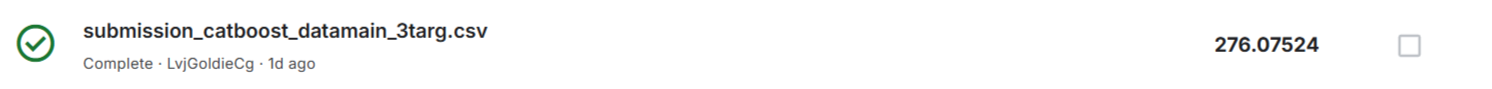

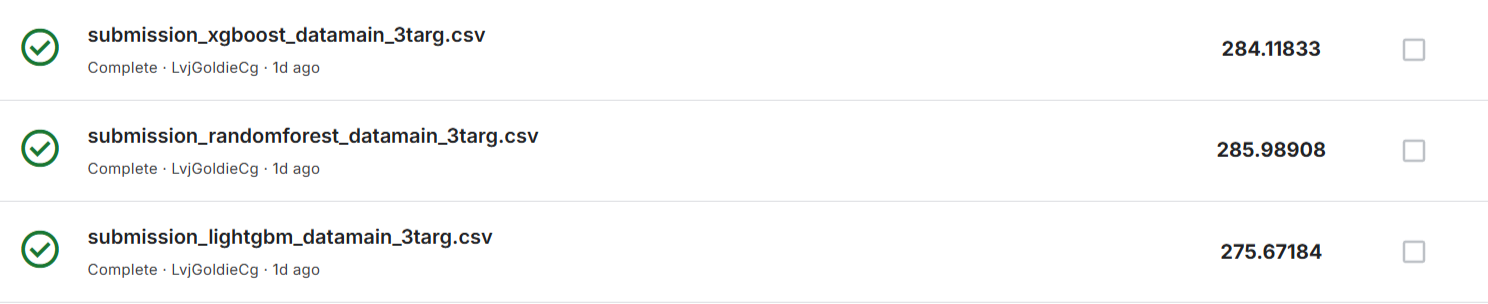

После очистки датасета от практически полных дубликатов результаты на Kaggle улучшились. CatBoost показал заметный рост качества, в то время как LightGBM продемонстрировал практически неизменный результат по сравнению с предыдущей версией.
Таким образом, CatBoost и LightGBM по-прежнему остаются двумя лучшими моделями на текущем этапе. Для дальнейшего повышения качества будет проведена оптимизация гиперпараметров этих алгоритмов с помощью Optuna с учётом обновлённого датасета.

## Optuna — общая функция (использует custom_rmse)

In [ ]:
def objective(trial, model_name, target_idx):
    if model_name == 'CatBoost':
        params = {
            'iterations': 500,
            'depth': trial.suggest_int('depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'random_seed': SEED, 'verbose': 0,
        }
        model = CatBoostRegressor(**params)
    else:
        params = {
            'n_estimators': 500,
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
            'random_state': SEED, 'verbose': -1,
        }
        model = LGBMRegressor(**params)

    scores = []
    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    for train_idx, val_idx in kf.split(X):
        model.fit(X[train_idx], y[train_idx, target_idx])
        pred = model.predict(X[val_idx])

        preds_oof = np.zeros((len(val_idx), 3))
        preds_oof[:, target_idx] = pred
        y_true = np.zeros((len(val_idx), 3))
        y_true[:, target_idx] = y_orig[val_idx, target_idx]
        y_pred = np.zeros((len(val_idx), 3))
        y_pred[:, target_idx] = np.clip(pred, 0, None)**2

        scores.append(custom_rmse(
            y_true[:, 0], y_true[:, 1], y_true[:, 2],
            y_pred[:, 0], y_pred[:, 1], y_pred[:, 2]
        ))
    return np.mean(scores)

## Запуск Optuna для CatBoost и LightGBM

In [ ]:
optuna_results = {}

for model_name in ['CatBoost', 'LightGBM']:
    optuna_results[model_name] = {}
    for target_idx in range(3):
        study = optuna.create_study(direction='minimize')
        study.optimize(lambda trial: objective(trial, model_name, target_idx), n_trials=30)
        optuna_results[model_name][target_idx] = study
        print(f"{model_name} {TARGETS_ORIG[target_idx]}: RMSE={study.best_value:.2f}")

[I 2026-05-29 14:12:58,346] A new study created in memory with name: no-name-7af3f9e2-cc2a-4a07-be62-b83cf9d4363a
[I 2026-05-29 14:13:53,551] Trial 0 finished with value: 109.44066634430807 and parameters: {'depth': 7, 'learning_rate': 0.06397233946298317, 'l2_leaf_reg': 9, 'subsample': 0.6822802064428029}. Best is trial 0 with value: 109.44066634430807.
[I 2026-05-29 14:14:06,064] Trial 1 finished with value: 113.03381408267374 and parameters: {'depth': 4, 'learning_rate': 0.01155190227583226, 'l2_leaf_reg': 6, 'subsample': 0.8524363482885602}. Best is trial 0 with value: 109.44066634430807.
[I 2026-05-29 14:14:37,645] Trial 2 finished with value: 108.95458100236836 and parameters: {'depth': 6, 'learning_rate': 0.06490259472920337, 'l2_leaf_reg': 7, 'subsample': 0.9612425000636425}. Best is trial 2 with value: 108.95458100236836.
[I 2026-05-29 14:16:18,153] Trial 3 finished with value: 109.72177248884812 and parameters: {'depth': 8, 'learning_rate': 0.04228628640336077, 'l2_leaf_reg':

CatBoost IC50, mM: RMSE=108.14


[I 2026-05-29 14:29:00,855] Trial 0 finished with value: 157.01943485251263 and parameters: {'depth': 3, 'learning_rate': 0.02874288711756023, 'l2_leaf_reg': 5, 'subsample': 0.9772186156878898}. Best is trial 0 with value: 157.01943485251263.
[I 2026-05-29 14:29:54,947] Trial 1 finished with value: 158.03988416083567 and parameters: {'depth': 7, 'learning_rate': 0.016689152529692542, 'l2_leaf_reg': 2, 'subsample': 0.7397565888780949}. Best is trial 0 with value: 157.01943485251263.
[I 2026-05-29 14:30:49,664] Trial 2 finished with value: 161.0509376565607 and parameters: {'depth': 7, 'learning_rate': 0.015207805808656171, 'l2_leaf_reg': 9, 'subsample': 0.8140632505871885}. Best is trial 0 with value: 157.01943485251263.
[I 2026-05-29 14:32:29,237] Trial 3 finished with value: 158.44785955645526 and parameters: {'depth': 8, 'learning_rate': 0.02923353029534632, 'l2_leaf_reg': 5, 'subsample': 0.8608118006910611}. Best is trial 0 with value: 157.01943485251263.
[I 2026-05-29 14:33:23,562]

CatBoost CC50, mM: RMSE=156.14


[I 2026-05-29 14:44:16,202] Trial 0 finished with value: 41.262532911623715 and parameters: {'depth': 8, 'learning_rate': 0.011278888614366133, 'l2_leaf_reg': 3, 'subsample': 0.8840235906274128}. Best is trial 0 with value: 41.262532911623715.
[I 2026-05-29 14:44:48,096] Trial 1 finished with value: 41.291245603895625 and parameters: {'depth': 6, 'learning_rate': 0.017073019187120675, 'l2_leaf_reg': 6, 'subsample': 0.8932192614792227}. Best is trial 0 with value: 41.262532911623715.
[I 2026-05-29 14:45:42,218] Trial 2 finished with value: 42.26459472793266 and parameters: {'depth': 7, 'learning_rate': 0.04004465454601171, 'l2_leaf_reg': 4, 'subsample': 0.918872269455119}. Best is trial 0 with value: 41.262532911623715.
[I 2026-05-29 14:46:01,938] Trial 3 finished with value: 41.913104890424606 and parameters: {'depth': 5, 'learning_rate': 0.024121663121153245, 'l2_leaf_reg': 1, 'subsample': 0.790267590648217}. Best is trial 0 with value: 41.262532911623715.
[I 2026-05-29 14:47:40,715] 

...

LightGBM IC50, mM: RMSE=107.83


[I 2026-05-29 15:01:42,772] Trial 0 finished with value: 161.6042180942571 and parameters: {'max_depth': 3, 'learning_rate': 0.021223436090513997, 'subsample': 0.6227023915611255, 'reg_lambda': 6.890053536310925}. Best is trial 0 with value: 161.6042180942571.
[I 2026-05-29 15:01:45,486] Trial 1 finished with value: 162.42422758483565 and parameters: {'max_depth': 5, 'learning_rate': 0.015836143313557236, 'subsample': 0.9469415857542075, 'reg_lambda': 7.23454235670311}. Best is trial 0 with value: 161.6042180942571.
[I 2026-05-29 15:01:48,508] Trial 2 finished with value: 160.97662877597872 and parameters: {'max_depth': 8, 'learning_rate': 0.020106600709450202, 'subsample': 0.7790838227752502, 'reg_lambda': 0.1784753523141285}. Best is trial 2 with value: 160.97662877597872.
[I 2026-05-29 15:01:50,457] Trial 3 finished with value: 164.05906675318172 and parameters: {'max_depth': 5, 'learning_rate': 0.03712533706002204, 'subsample': 0.9940496109730101, 'reg_lambda': 5.316850071274849}. 

LightGBM CC50, mM: RMSE=159.00


[I 2026-05-29 15:02:39,181] Trial 0 finished with value: 41.23922598908046 and parameters: {'max_depth': 7, 'learning_rate': 0.015201180553475462, 'subsample': 0.6937416378565416, 'reg_lambda': 0.12624828210085995}. Best is trial 0 with value: 41.23922598908046.
[I 2026-05-29 15:02:40,871] Trial 1 finished with value: 41.65506763418816 and parameters: {'max_depth': 4, 'learning_rate': 0.02484549876548947, 'subsample': 0.9034840958780035, 'reg_lambda': 0.5691868541387957}. Best is trial 0 with value: 41.23922598908046.
[I 2026-05-29 15:02:42,935] Trial 2 finished with value: 43.160405554133256 and parameters: {'max_depth': 5, 'learning_rate': 0.07020443494804872, 'subsample': 0.6703577567531658, 'reg_lambda': 1.3958271069828005}. Best is trial 0 with value: 41.23922598908046.
[I 2026-05-29 15:02:45,339] Trial 3 finished with value: 43.748042497834895 and parameters: {'max_depth': 6, 'learning_rate': 0.0973061829607231, 'subsample': 0.6653060663172852, 'reg_lambda': 0.9911331222327139}. 

LightGBM SI: RMSE=41.05


## Лучшие параметры Optuna

In [ ]:
for model_name in ['CatBoost', 'LightGBM']:
    print(f"\n{model_name}:")
    for target_idx in range(3):
        study = optuna_results[model_name][target_idx]
        print(f"  {TARGETS_ORIG[target_idx]}: {study.best_params}")


CatBoost:
  IC50, mM: {'depth': 5, 'learning_rate': 0.02709999992397344, 'l2_leaf_reg': 1, 'subsample': 0.7476355171722926}
  CC50, mM: {'depth': 4, 'learning_rate': 0.0241013389197966, 'l2_leaf_reg': 3, 'subsample': 0.8877622414853001}
  SI: {'depth': 5, 'learning_rate': 0.012018565373689559, 'l2_leaf_reg': 2, 'subsample': 0.6164258079432023}

LightGBM:
  IC50, mM: {'max_depth': 5, 'learning_rate': 0.021788488692750883, 'subsample': 0.9387091172008597, 'reg_lambda': 1.365472013970663}
  CC50, mM: {'max_depth': 4, 'learning_rate': 0.017991961777159393, 'subsample': 0.6452081875806877, 'reg_lambda': 0.8777030757875498}
  SI: {'max_depth': 7, 'learning_rate': 0.010189057012342972, 'subsample': 0.7553246788874474, 'reg_lambda': 0.32102086469519336}


С помощью Optuna были подобраны новые оптимальные гиперпараметры для CatBoost и LightGBM на очищенном датасете.

## Submissions для CatBoost и LightGBM

In [ ]:
for model_name in ['CatBoost', 'LightGBM']:
    study_dict = optuna_results[model_name]
    preds_test_optuna = np.zeros((len(X_test), 3))

    for target_idx in range(3):
        best_params = study_dict[target_idx].best_params
        if model_name == 'CatBoost':
            model = CatBoostRegressor(
                iterations=500, depth=best_params['depth'],
                learning_rate=best_params['learning_rate'],
                l2_leaf_reg=best_params['l2_leaf_reg'],
                subsample=best_params['subsample'],
                random_seed=SEED, verbose=0
            )
        else:
            model = LGBMRegressor(
                n_estimators=500, max_depth=best_params['max_depth'],
                learning_rate=best_params['learning_rate'],
                subsample=best_params['subsample'],
                reg_lambda=best_params['reg_lambda'],
                random_state=SEED, verbose=-1
            )
        model.fit(X, y[:, target_idx])
        preds_test_optuna[:, target_idx] = model.predict(X_test)

    preds_test_orig = preds_test_optuna ** 2
    submission = pd.DataFrame({
        'index': np.arange(len(preds_test_orig)),
        'IC50': preds_test_orig[:, 0],
        'CC50': preds_test_orig[:, 1],
        'SI': preds_test_orig[:, 2]
    })
    submission.to_csv(f'submission_{model_name.lower()}_datamain_3targ_OPTUNA.csv', index=False)
    print(f"Сохранён: submission_{model_name.lower()}_datamain_3targ_OPTUNA.csv")

Сохранён: submission_catboost_datamain_3targ_OPTUNA.csv
Сохранён: submission_lightgbm_datamain_3targ_OPTUNA.csv


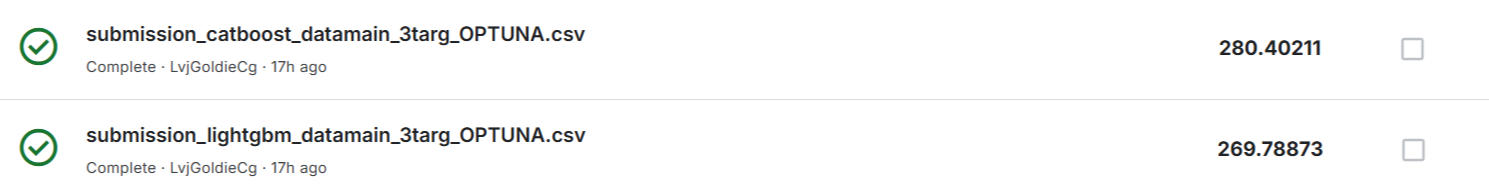

После применения новых гиперпараметров, подобранных Optuna на очищенном датасете, результаты моделей изменились следующим образом:
CatBoost показал ухудшение качества — RMSE выросло с 273 до 280. Это говорит о том, что найденные параметры привели к недостаточной сложности модели или избыточной регуляризации.
В то же время LightGBM удалось значительно улучшить результат: RMSE снизилось до 269, что стало новым лучшим показателем и позволило пробить предыдущий потолок в 273. Это подтверждает высокую эффективность оптимизации именно для LightGBM на текущих данных.
Таким образом, на данный момент LightGBM с подобранными параметрами является самой сильной моделью.